# 01 EDA: まずデータを確認する(S6E10 Predicting Airline Satisfaction)

目的: 特徴量を考える前に、データの形・target・欠損・train/test の違いを押さえる。

- 1セル = 1つの問い。各問いの下の「見えたこと」は自分で書く(事実 / 比較 / 理由の仮説 / 次の行動)
- 図は `eda_figs/` に保存される

## 準備: 読み込み

In [1]:
# ライブラリを読み込む
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 表を表示するとき、100列まで・幅200文字まで省略せずに出す
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# データの置き場所(Kaggle)
DATA = Path("/kaggle/input/playground-series-s6e10")

# id の列の名前と、予測する列(target)の名前
ID = "id"
TARGET = "satisfaction"

# 図の色を決める
# train=青、test=橙(全図で共通)。図の中の文字は英語(Kaggleに日本語フォントがないため)
TRAIN_C = "#2a78d6"
TEST_C = "#eb6834"
# target: False=マゼンタ、True=アクア(train/testの青・橙と区別するため)
FALSE_C = "#e87ba4"
TRUE_C = "#1baf7a"

# 図を保存するフォルダを作る(すでにあってもOK)
FIG = Path("eda_figs")
FIG.mkdir(exist_ok=True)

# train.csv と test.csv を読み込む
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")

# 配布ファイルの一覧を表示する(original データがあるかも確認できる)
print([p.name for p in DATA.iterdir()])

['train.csv', 'test.csv', 'sample_submission.csv']


## Q1. データの大きさと列は? train と test で列は揃っているか?
なぜ見るか: 行数で使える手法・CV の重さが決まる。列の差が target 以外にあれば前処理で揃える必要がある。

予想: test は train に比べて target 列がないだけ。

In [2]:
# trainとtestの大きさ(行数, 列数)を表示する
print("train.shape:", train.shape)
print("test.shape:", test.shape)

# trainにだけある列 / testにだけある列を調べる
# 列の名前を「集合」にして、引き算で差を出す
train_only = sorted(set(train.columns) - set(test.columns))
test_only = sorted(set(test.columns) - set(train.columns))
print("train にだけある列:", train_only)
print("test にだけある列:", test_only)

# 先頭5行を表示する
# 列が多くて横に切れるので .T で行と列を入れ替える(列=縦、0〜4=先頭5行)
display(train.head().T)
display(test.head().T)

train.shape: (699635, 23)
test.shape: (299844, 22)
train にだけある列: ['satisfaction']
test にだけある列: []


,0,1,2,3,4
id,0,1,2,3,4
Age,36,56,31,10,23
Flight Distance,694,651,1371,1616,481
Inflight wifi service,4,5,3,3,3
Departure/Arrival time convenient,4,5,4,5,4
Ease of Online booking,4,5,2,3,3
Gate location,3,5,5,3,4
Food and drink,1,5,3,3,5
Online boarding,4,4,3,3,3
Seat comfort,1,4,3,3,5


,0,1,2,3,4
id,699635,699636,699637,699638,699639
Age,25,36,45,45,34
Flight Distance,1197,829,472,762,594
Inflight wifi service,4,5,4,2,1
Departure/Arrival time convenient,4,5,5,2,2
Ease of Online booking,4,5,5,2,1
Gate location,2,5,5,5,1
Food and drink,3,5,4,3,2
Online boarding,4,4,4,2,1
Seat comfort,3,5,4,3,2


**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q2. 各列の型とユニーク数は?(どれがカテゴリ列か)
なぜ見るか: カテゴリ列の扱い(category 型 / エンコード)と、数値に見えて実は段階評価の列を見分けるため。

予想: 文字列のカテゴリ列が数本、0〜5 の満足度評価の整数列が多数、遅延や距離などの連続値が少し。

In [3]:
# id以外の列の名前を集める(testの列を順に見て、idは入れない)
cols = []
for c in test.columns:
    if c != ID:
        cols.append(c)

# 列ごとに、型とユニーク数(種類の数)を表にまとめる
info = pd.DataFrame({
    "dtype": train[cols].dtypes.astype(str),
    "nunique_train": train[cols].nunique(),
    "nunique_test": test[cols].nunique(),
})

# trainとtestでユニーク数がどれだけ違うか(test - train)
info["diff(test-train)"] = info["nunique_test"] - info["nunique_train"]

# testにだけある値の数 / trainにだけある値の数 を、列ごとに数える
only_test_list = []
only_train_list = []
for c in cols:
    train_values = set(train[c].dropna())
    test_values = set(test[c].dropna())
    only_test_list.append(len(test_values - train_values))
    only_train_list.append(len(train_values - test_values))
info["only_test"] = only_test_list
info["only_train"] = only_train_list

# 例として、先頭の6種類の値を出す
examples = []
for c in cols:
    examples.append(train[c].dropna().unique()[:6].tolist())
info["例"] = examples

# targetの種類の数を表示してから、表を表示する
print("target の種類数:", train[TARGET].nunique())
info

target の種類数: 2


,dtype,nunique_train,nunique_test,diff(test-train),only_test,only_train,例
Age,int64,75,75,0,0,0,"[36, 56, 31, 10, 23, 34]"
Flight Distance,int64,3474,3317,-157,47,204,"[694, 651, 1371, 1616, 481, 584]"
Inflight wifi service,int64,6,6,0,0,0,"[4, 5, 3, 1, 2, 0]"
Departure/Arrival time convenient,int64,6,6,0,0,0,"[4, 5, 3, 2, 0, 1]"
Ease of Online booking,int64,6,6,0,0,0,"[4, 5, 2, 3, 1, 0]"
Gate location,int64,6,6,0,0,0,"[3, 5, 4, 2, 1, 0]"
Food and drink,int64,6,6,0,0,0,"[1, 5, 3, 4, 2, 0]"
Online boarding,int64,6,6,0,0,0,"[4, 3, 2, 1, 5, 0]"
Seat comfort,int64,6,6,0,0,0,"[1, 4, 3, 5, 2, 0]"
Inflight entertainment,int64,6,6,0,0,0,"[1, 5, 3, 4, 2, 0]"


以降は「文字列の列 + ユニーク数が10以下の数値列」をカテゴリ扱い、それ以外を連続値として見る。

In [4]:
# 列を「カテゴリ扱い」と「連続値」に振り分ける
# 文字列の列、または、ユニーク数が10以下の列 → カテゴリ扱い。それ以外 → 連続値
cat_cols = []
num_cols = []
for c in cols:
    # 文字列の列か(型が object または str)
    is_text = train[c].dtype in ("object", "str")
    # ユニーク数が10以下か
    is_few = train[c].nunique() <= 10
    if is_text or is_few:
        cat_cols.append(c)
    else:
        num_cols.append(c)

print("カテゴリ扱い:", cat_cols)
print("連続値:", num_cols)

カテゴリ扱い: ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Gender', 'Customer Type', 'Type of Travel', 'Class']
連続値: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q4. 欠損はどの列にどれくらいあるか? train と test で同じか?
なぜ見るか: 欠損の扱い(そのまま LightGBM に任せる / 補完 / 欠損フラグ)を決めるため。train と test で率が違えば要注意。

,train,test
Age,0,0.0
Arrival Delay in Minutes,292,130.0
Baggage handling,0,0.0
Checkin service,0,0.0
Class,0,0.0
Cleanliness,0,0.0
Customer Type,0,0.0
Departure Delay in Minutes,0,0.0
Departure/Arrival time convenient,0,0.0
Ease of Online booking,0,0.0


                           train    test
Arrival Delay in Minutes  0.0004  0.0004


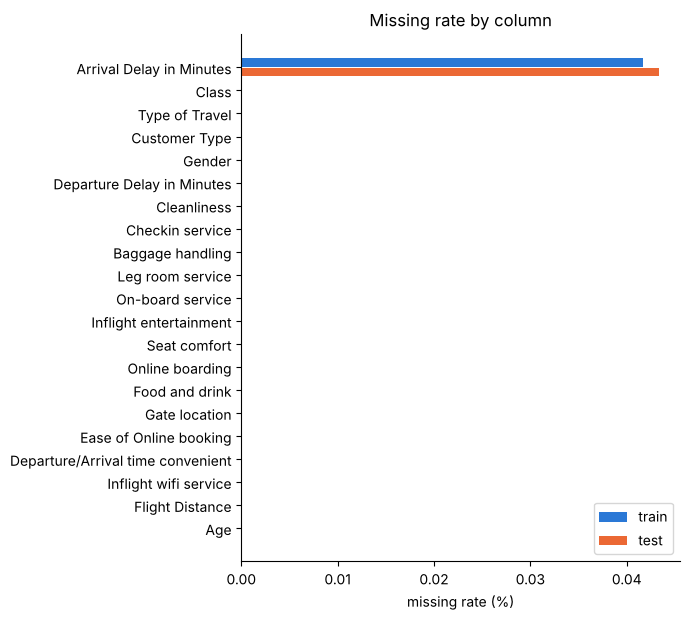

In [5]:
# 欠損の件数を表にして表示する
# test には target 列がないので、その行は NaN になる
missing_count = pd.DataFrame({"train": train.isnull().sum(), "test": test.isnull().sum()})
display(missing_count)

# 欠損の割合(0〜1)を、id以外の列ごとに出す
miss = pd.DataFrame({
    "train": train[cols].isna().mean(),
    "test": test[cols].isna().mean(),
})

# 欠損が1つでもある列だけを、割合の大きい順に表示する
has_missing = miss[(miss > 0).any(axis=1)]
print(has_missing.sort_values("train", ascending=False).round(4))

# 図用に、割合の小さい順に並べる(横棒グラフは下から上に並ぶため)
m = miss.sort_values("train")

# 棒を置く位置(0, 1, 2, ...)
y = np.arange(len(m))

# 横棒グラフを描く(trainとtestを少しずらして並べる)
fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(m))))
ax.barh(y + 0.2, m["train"] * 100, height=0.38, color=TRAIN_C, label="train")
ax.barh(y - 0.2, m["test"] * 100, height=0.38, color=TEST_C, label="test")
ax.set_yticks(y, m.index)
ax.set_xlabel("missing rate (%)")
ax.set_title("Missing rate by column")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

# 図を保存して表示する
plt.savefig(FIG / "q4_missing.png", dpi=120)
plt.show()

**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q5. 連続値の列の分布は? train と test でズレていないか?
なぜ見るか: 外れ値・裾の長さ(log 変換が要るか)と、train/test の分布のズレ(CV と LB が乖離する原因)を確認するため。

予想: 遅延時間は 0 に集中して右に長い裾。train と test はほぼ重なる。

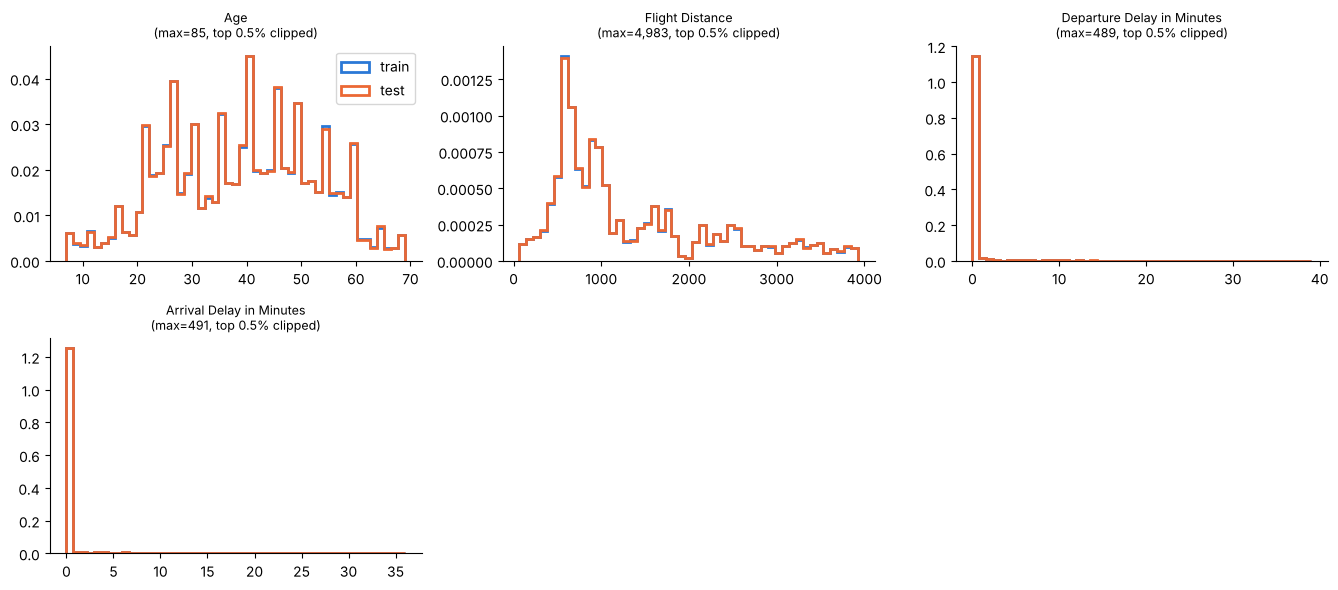

,count,mean,std,min,25%,50%,75%,max
Age,699635.0,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Departure Delay in Minutes,699635.0,1.176209,5.982187,0.0,0.0,0.0,0.0,489.0
Arrival Delay in Minutes,699343.0,1.134280,5.749304,0.0,0.0,0.0,0.0,491.0


In [6]:
# 連続値の列を、trainとtestで重ねたヒストグラムで描く(割合にそろえる)

# 描く列の数と、図の行数・列数を決める(3列ずつ並べる)
n = len(num_cols)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3 * nrow), squeeze=False)

# 列を1つずつ描く
for k in range(n):
    # k番目の列の名前を取り出す
    c = num_cols[k]

    # この列を置く場所を決める(k // 3 = 何行目、k % 3 = 何列目)
    ax = axes[k // ncol, k % ncol]

    # 横軸の範囲を決める(trainとtestをまとめて、最小値 〜 上位0.5%の手前まで)
    all_values = pd.concat([train[c], test[c]])
    lo = np.nanpercentile(all_values, 0)
    hi = np.nanpercentile(all_values, 99.5)

    # 範囲を50個に区切る(ヒストグラムの棒の幅)
    bins = np.linspace(lo, hi, 50)

    # ヒストグラムを描く(train=青、test=橙)
    ax.hist(train[c].dropna(), bins=bins, density=True, histtype="step", lw=2, color=TRAIN_C, label="train")
    ax.hist(test[c].dropna(), bins=bins, density=True, histtype="step", lw=2, color=TEST_C, label="test")
    ax.set_title(f"{c}\n(max={train[c].max():,.0f}, top 0.5% clipped)", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

# 余ったマスは消す
for k in range(n, nrow * ncol):
    axes[k // ncol, k % ncol].axis("off")

# 凡例を出して、図を保存して表示する
axes[0, 0].legend()
plt.tight_layout()
plt.savefig(FIG / "q5_numeric_dist.png", dpi=120)
plt.show()

# 数値の要約(平均・中央値など)を表示する
train[num_cols].describe().T

In [7]:
# 図を文字の表にしたもの(区間ごとの割合 %)。trainとtestを並べる
inf = np.inf

# 遅延(分)の区切り方と、区間の名前
delay_edges = [0, 1, 6, 16, 31, 61, 121, inf]
delay_labels = ["0", "1-5", "6-15", "16-30", "31-60", "61-120", "121+"]

# 列ごとの区切り方を辞書にまとめる(列の名前 → (区切りの数値, 区間の名前))
bins_spec = {
    "Age": ([0, 10, 20, 30, 40, 50, 60, 70, 80, inf],
            ["<10", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]),
    "Flight Distance": ([0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, inf],
                        ["<500", "500-999", "1000-1499", "1500-1999", "2000-2499", "2500-2999", "3000-3499", "3500-3999", "4000+"]),
    "Departure Delay in Minutes": (delay_edges, delay_labels),
    "Arrival Delay in Minutes": (delay_edges, delay_labels),
}

# 列ごとに、区間に分けて割合を数えて表示する
for c in bins_spec:
    edges = bins_spec[c][0]
    labels = bins_spec[c][1]

    # 区間に分けて、割合を数える(区間の順に並べる)
    train_share = pd.cut(train[c], edges, labels=labels, right=False).value_counts(normalize=True).reindex(labels)
    test_share = pd.cut(test[c], edges, labels=labels, right=False).value_counts(normalize=True).reindex(labels)

    # %にして、小数第2位までで表示する
    print("==", c, "==")
    display(pd.DataFrame({"train(%)": (train_share * 100).round(2), "test(%)": (test_share * 100).round(2)}))

# パーセンタイル(trainの値 / testの値)を列ごとに出す
qs = [0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
percent_table = {}
for c in num_cols:
    row = []
    for q in qs:
        train_q = train[c].quantile(q)
        test_q = test[c].quantile(q)
        row.append(f"{train_q:.0f} / {test_q:.0f}")
    percent_table[c] = row
display(pd.DataFrame(percent_table, index=["50%", "90%", "99%", "99.5%", "99.9%", "max"]).T)

== Age ==


,train(%),test(%)
Age,,
<10,1.26,1.26
10-19,5.83,5.81
20-29,22.36,22.34
30-39,20.16,20.23
40-49,25.16,25.25
50-59,19.34,19.24
60-69,5.43,5.44
70-79,0.44,0.43
80+,0.01,0.01


== Flight Distance ==


,train(%),test(%)
Flight Distance,,
<500,9.77,9.82
500-999,43.47,43.46
1000-1499,12.38,12.37
1500-1999,10.88,10.85
2000-2499,8.41,8.42
2500-2999,5.66,5.70
3000-3499,5.64,5.61
3500-3999,3.76,3.74
4000+,0.03,0.03


== Departure Delay in Minutes ==


,train(%),test(%)
Departure Delay in Minutes,,
0,90.78,90.84
1-5,3.69,3.66
6-15,2.87,2.83
16-30,1.71,1.73
31-60,0.90,0.90
61-120,0.02,0.02
121+,0.03,0.02


== Arrival Delay in Minutes ==


,train(%),test(%)
Arrival Delay in Minutes,,
0,91.57,91.57
1-5,2.74,2.74
6-15,3.02,3.06
16-30,1.84,1.82
31-60,0.78,0.77
61-120,0.01,0.02
121+,0.03,0.02


,50%,90%,99%,99.5%,99.9%,max
Age,40 / 40,57 / 57,68 / 68,69 / 69,70 / 70,85 / 85
Flight Distance,954 / 954,2933 / 2928,3873 / 3868,3929 / 3927,3995 / 3995,4983 / 4983
Departure Delay in Minutes,0 / 0,0 / 0,30 / 30,39 / 38,52 / 52,489 / 480
Arrival Delay in Minutes,0 / 0,0 / 0,28 / 28,36 / 36,49 / 49,491 / 471


**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q6. カテゴリ列の分布は? train と test でズレていないか?
なぜ見るか: 少数カテゴリ・test にしかない値の有無と、train/test の比率の差を確認するため。

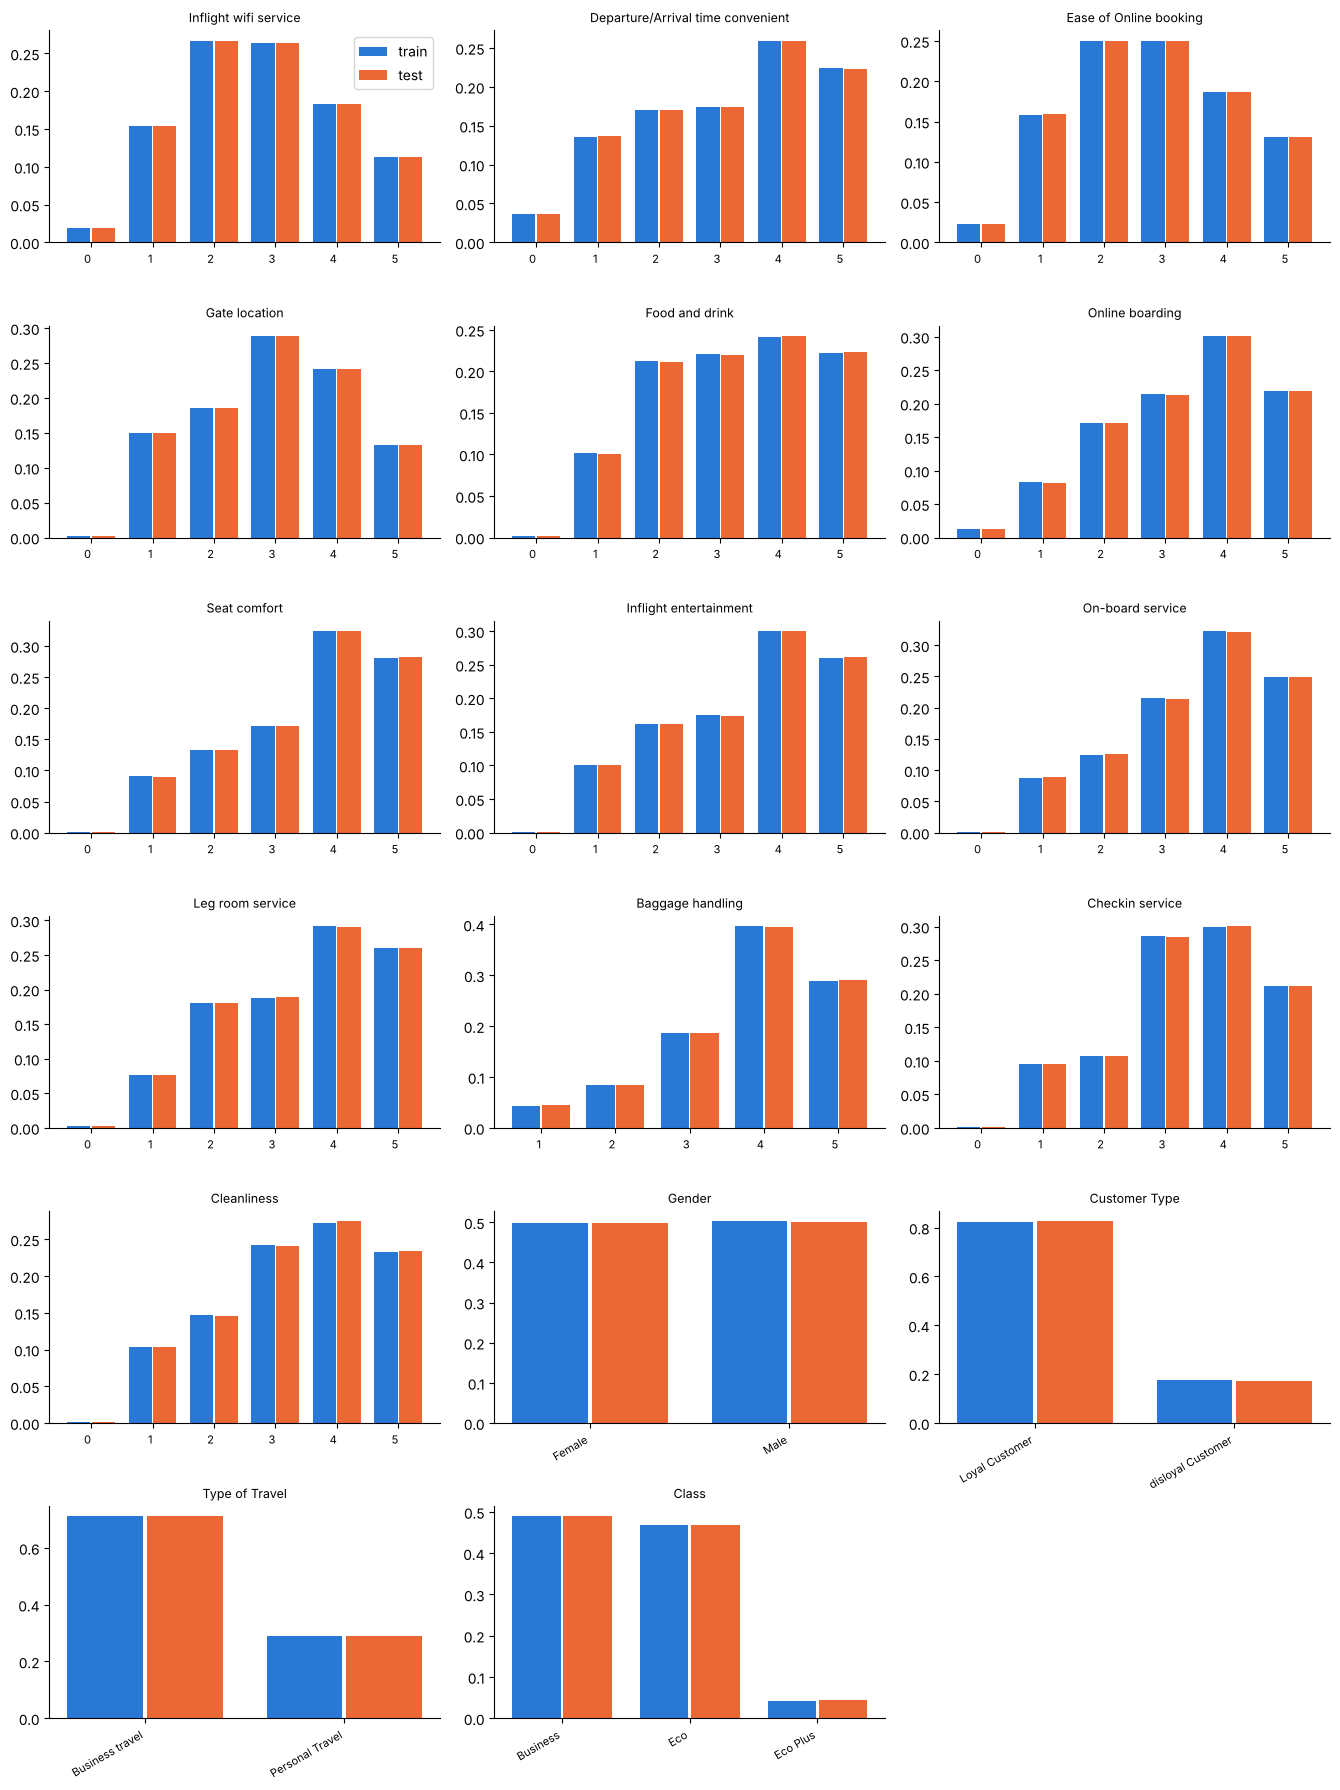

test にだけある値: なし


In [8]:
# カテゴリ扱いの列を、trainとtestで並べた棒グラフで描く(割合)

# 描く列の数と、図の行数・列数を決める(3列ずつ並べる)
n = len(cat_cols)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3 * nrow), squeeze=False)

# 列を1つずつ描く
for k in range(n):
    # k番目の列の名前を取り出す
    c = cat_cols[k]

    # この列を置く場所を決める(k // 3 = 何行目、k % 3 = 何列目)
    ax = axes[k // ncol, k % ncol]

    # 値ごとの割合を数える(文字列にそろえて数える。片方にない値は0にする)
    p = pd.DataFrame({
        "train": train[c].astype(str).value_counts(normalize=True),
        "test": test[c].astype(str).value_counts(normalize=True),
    }).fillna(0).sort_index()

    # 棒を置く位置(0, 1, 2, ...)を決めて、trainを左、testを右に少しずらして描く
    x = np.arange(len(p))
    ax.bar(x - 0.2, p["train"], width=0.38, color=TRAIN_C, label="train")
    ax.bar(x + 0.2, p["test"], width=0.38, color=TEST_C, label="test")

    # 横軸のラベルが4文字より長いときは、斜め(30度)にする
    if p.index.str.len().max() > 4:
        angle = 30
    else:
        angle = 0
    ax.set_xticks(x, p.index, rotation=angle, ha="right", fontsize=8)
    ax.set_title(c, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

# 余ったマスは消す
for k in range(n, nrow * ncol):
    axes[k // ncol, k % ncol].axis("off")

# 凡例を出して、図を保存して表示する
axes[0, 0].legend()
plt.tight_layout()
plt.savefig(FIG / "q6_category_dist.png", dpi=120)
plt.show()

# testにだけある値を、列ごとに調べる
only_test = {}
for c in cat_cols:
    train_values = set(train[c].dropna().astype(str))
    test_values = set(test[c].dropna().astype(str))
    diff = sorted(test_values - train_values)
    if len(diff) > 0:
        only_test[c] = diff

# 1つもなければ「なし」と表示する
if len(only_test) == 0:
    print("test にだけある値: なし")
else:
    print("test にだけある値:", only_test)

**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q7. 各列の分布は、target(True / False)で違うか?
なぜ見るか: target と関係のありそうな列(分布が True と False で離れている列)を見つけて、特徴量やモデルの手がかりにするため。ヒストグラムは割合(density)で、箱ひげ図は中央値・四分位・外れ値で、True と False を比べる。

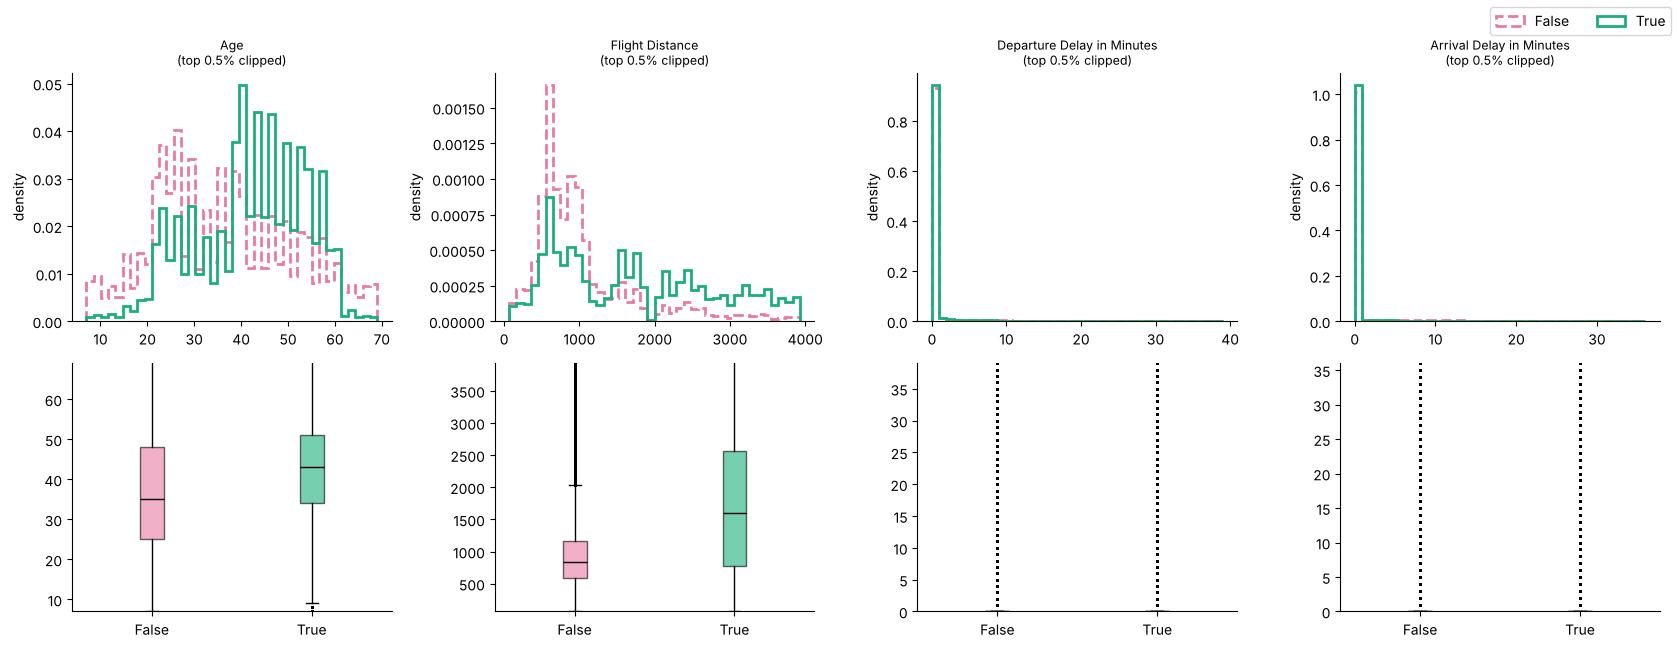

In [9]:
# 連続値の列を True / False で分けて比べる。上段=ヒストグラム、下段=箱ひげ図
# False=マゼンタの破線、True=アクアの実線

# trainを「Falseの行」と「Trueの行」に分ける
train_false = train[train[TARGET] == False]
train_true = train[train[TARGET] == True]

# 描く列の数を数える
n_cols = len(num_cols)

# 図を用意する(2行 × 列の数)
fig, axes = plt.subplots(2, n_cols, figsize=(4.2 * n_cols, 6.5), squeeze=False)

# 列を1つずつ描く
for j in range(n_cols):
    # j番目の列の名前を取り出す
    c = num_cols[j]

    # 横軸の範囲を決める(最小値 〜 上位0.5%の手前まで)
    lo = train[c].min()
    hi = np.nanpercentile(train[c], 99.5)

    # 範囲を40個に区切る(ヒストグラムの棒の幅)
    bins = np.linspace(lo, hi, 41)

    # Falseの行・Trueの行の値を取り出す(欠損は除く)
    values_false = train_false[c].dropna()
    values_true = train_true[c].dropna()

    # 上段: ヒストグラムを描く(density=True で割合にそろえる)
    ax_top = axes[0, j]
    ax_top.hist(values_false, bins=bins, density=True, histtype="step", lw=2, color=FALSE_C, ls="--", label="False")
    ax_top.hist(values_true, bins=bins, density=True, histtype="step", lw=2, color=TRUE_C, ls="-", label="True")
    ax_top.set_title(c + "\n(top 0.5% clipped)", fontsize=9)
    ax_top.set_ylabel("density")
    ax_top.spines[["top", "right"]].set_visible(False)

    # 下段: 箱ひげ図を描く
    ax_bottom = axes[1, j]
    bp = ax_bottom.boxplot([values_false, values_true], patch_artist=True,
                           flierprops=dict(marker=".", markersize=2, alpha=0.2),
                           medianprops=dict(color="black"))

    # 箱に色をつける(0番目=False、1番目=True)
    bp["boxes"][0].set_facecolor(FALSE_C)
    bp["boxes"][1].set_facecolor(TRUE_C)
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_alpha(0.6)

    # 横軸のラベルと、縦軸の範囲を決める
    ax_bottom.set_xticks([1, 2], ["False", "True"])
    ax_bottom.set_ylim(lo, hi)
    ax_bottom.spines[["top", "right"]].set_visible(False)

# 凡例は図の外(右上)に置く
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# 図を保存して表示する
plt.savefig(FIG / "q7_continuous_by_target.png", dpi=120)
plt.show()

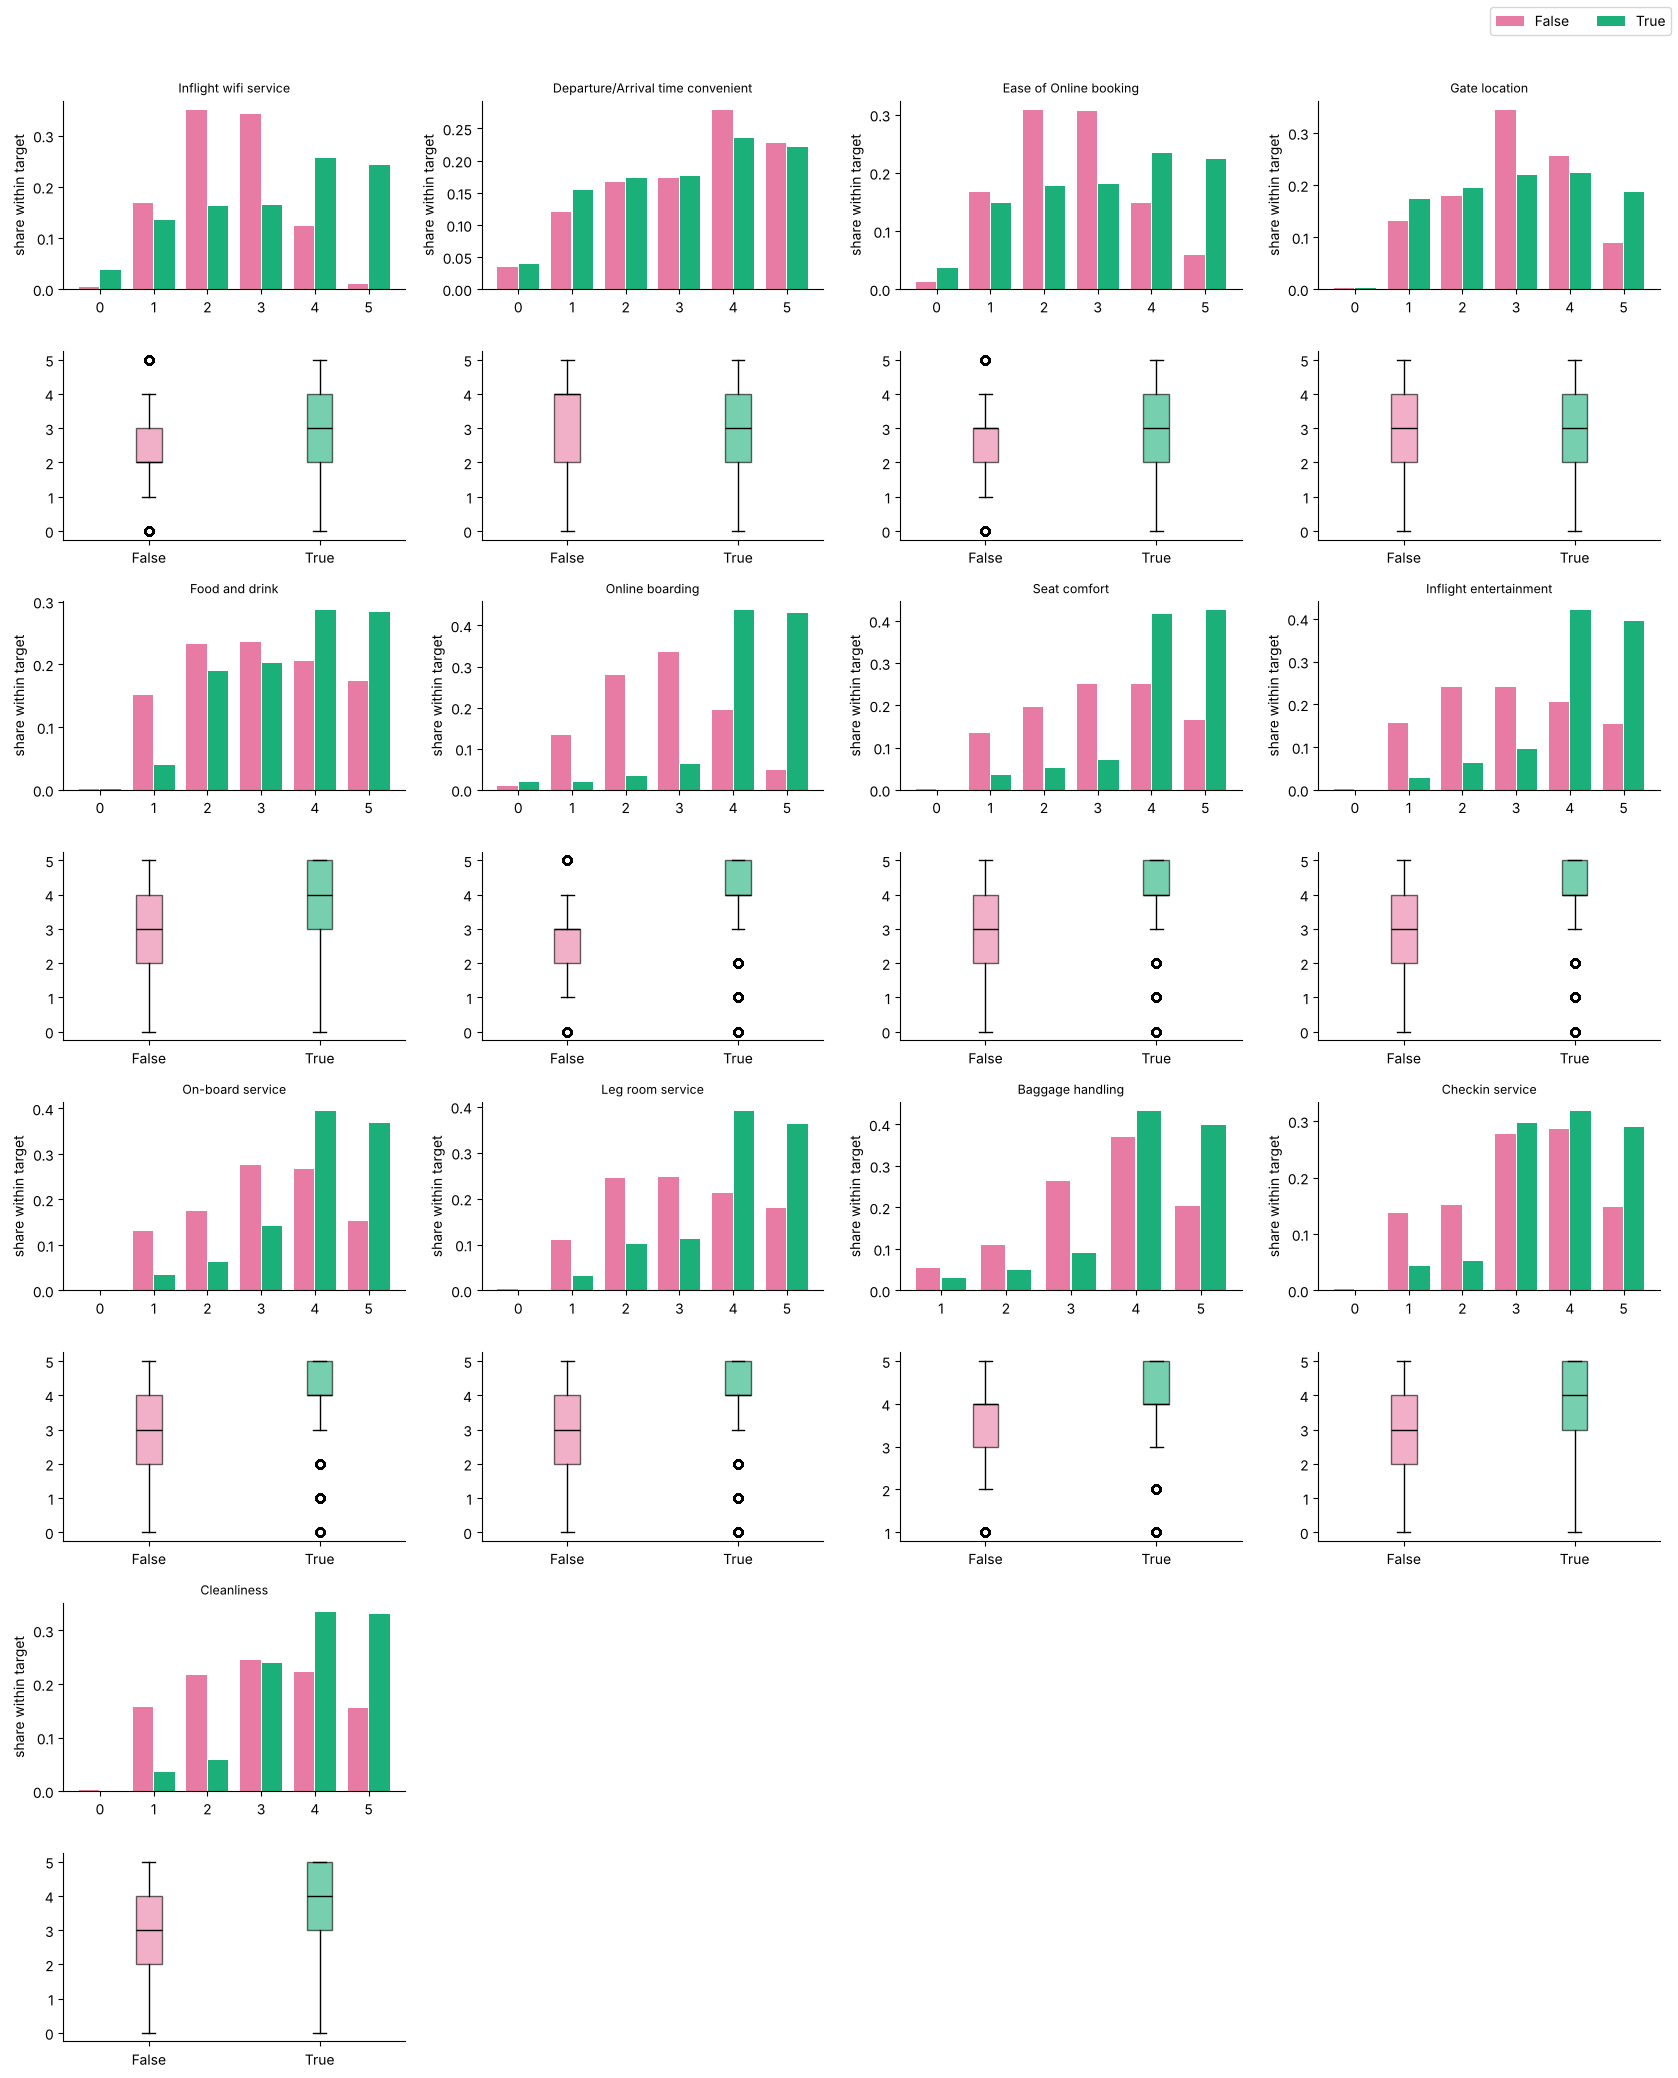

In [10]:
# 評価列(0〜5の整数)を True / False で分けて比べる。1列ごとに 上=ヒストグラム、下=箱ひげ図

# trainを「Falseの行」と「Trueの行」に分ける
train_false = train[train[TARGET] == False]
train_true = train[train[TARGET] == True]

# カテゴリ扱いの列のうち、数値の列(評価列)だけを集める
rate_cols = []
for c in cat_cols:
    if pd.api.types.is_numeric_dtype(train[c]):
        rate_cols.append(c)

# 1行に4列ずつ並べる。必要なグループ(上下2行のかたまり)の数を数える
n_per_row = 4
n_groups = int(np.ceil(len(rate_cols) / n_per_row))

# 図を用意する(1グループにつき 上=ヒストグラム、下=箱ひげ図 の2行)
fig, axes = plt.subplots(2 * n_groups, n_per_row, figsize=(4.2 * n_per_row, 5.2 * n_groups), squeeze=False)

# 列を1つずつ描く
for k in range(len(rate_cols)):
    # k番目の列の名前を取り出す
    c = rate_cols[k]

    # この列を置く場所を決める(k // 4 = 何番目のグループか、k % 4 = グループの中の何列目か)
    g = k // n_per_row
    j = k % n_per_row
    ax_top = axes[2 * g, j]
    ax_bottom = axes[2 * g + 1, j]

    # 評価の値(0〜5)を小さい順に並べる
    levels = np.sort(train[c].unique())

    # Falseの行・Trueの行で、評価ごとの割合を数える(いない値は0にする)
    share_false = train_false[c].value_counts(normalize=True).reindex(levels).fillna(0)
    share_true = train_true[c].value_counts(normalize=True).reindex(levels).fillna(0)

    # 上段: 棒グラフ(Falseを左に、Trueを右に少しずらして並べる)
    ax_top.bar(levels - 0.2, share_false.values, width=0.38, color=FALSE_C, label="False")
    ax_top.bar(levels + 0.2, share_true.values, width=0.38, color=TRUE_C, label="True")
    ax_top.set_xticks(levels)
    ax_top.set_title(c, fontsize=9)
    ax_top.set_ylabel("share within target")
    ax_top.spines[["top", "right"]].set_visible(False)

    # 下段: 箱ひげ図を描く
    bp = ax_bottom.boxplot([train_false[c], train_true[c]], patch_artist=True,
                           medianprops=dict(color="black"))

    # 箱に色をつける(0番目=False、1番目=True)
    bp["boxes"][0].set_facecolor(FALSE_C)
    bp["boxes"][1].set_facecolor(TRUE_C)
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_alpha(0.6)
    ax_bottom.set_xticks([1, 2], ["False", "True"])
    ax_bottom.spines[["top", "right"]].set_visible(False)

# 余ったマスは消す
for k in range(len(rate_cols), n_groups * n_per_row):
    g = k // n_per_row
    j = k % n_per_row
    axes[2 * g, j].axis("off")
    axes[2 * g + 1, j].axis("off")

# 凡例は図の外(右上)に置く
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# 図を保存して表示する
plt.savefig(FIG / "q7_ratings_by_target.png", dpi=120)
plt.show()

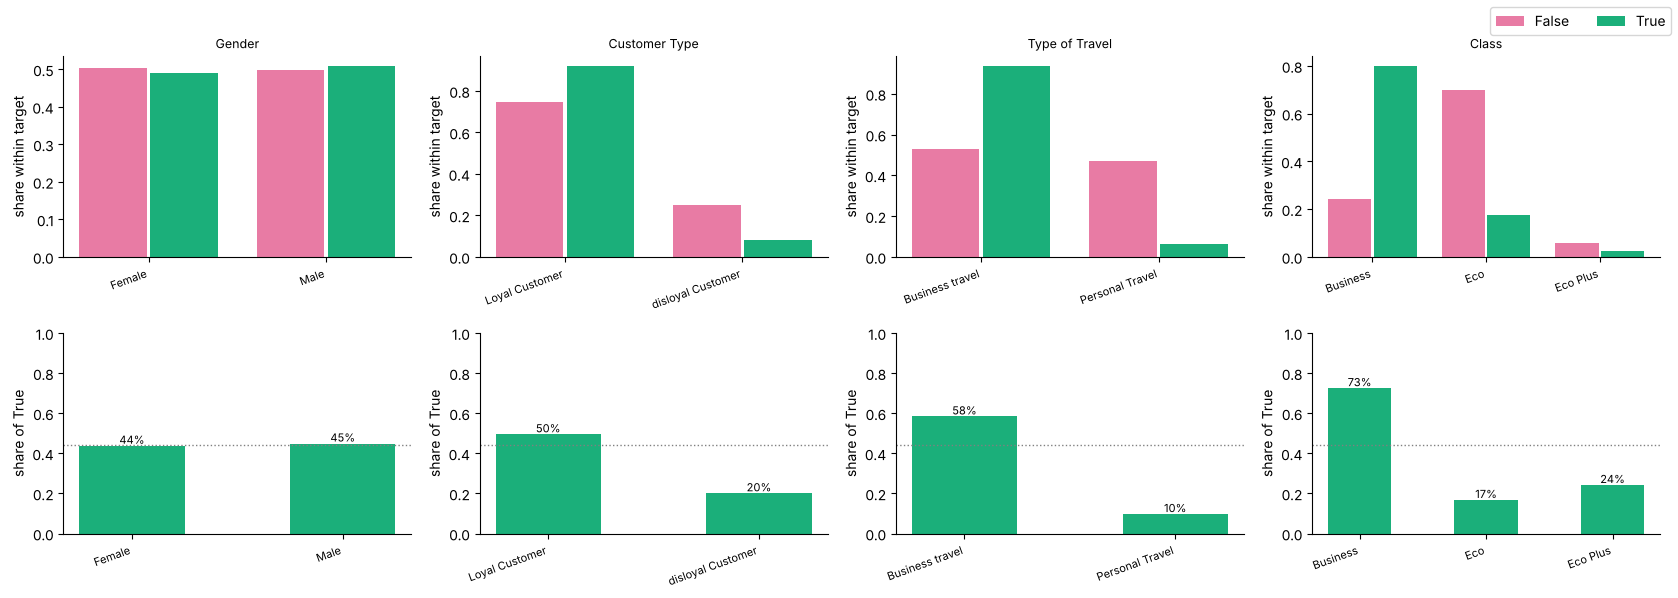

In [11]:
# 文字列の列(カテゴリ)を True / False で分けて比べる
# 箱ひげ図は作れないので、上=ヒストグラム相当(割合)、下=カテゴリごとの True の割合

# trainを「Falseの行」と「Trueの行」に分ける
train_false = train[train[TARGET] == False]
train_true = train[train[TARGET] == True]

# カテゴリ扱いの列のうち、文字列の列だけを集める
str_cols = []
for c in cat_cols:
    if not pd.api.types.is_numeric_dtype(train[c]):
        str_cols.append(c)

# 図を用意する(2行 × 列の数)
n_cols = len(str_cols)
fig, axes = plt.subplots(2, n_cols, figsize=(4.2 * n_cols, 6), squeeze=False)

# 列を1つずつ描く
for j in range(n_cols):
    # j番目の列の名前を取り出す
    c = str_cols[j]

    # カテゴリの種類を並べて、棒を置く位置(0, 1, 2...)を決める
    levels = sorted(train[c].unique())
    x = np.arange(len(levels))

    # Falseの行・Trueの行で、カテゴリごとの割合を数える
    share_false = train_false[c].value_counts(normalize=True).reindex(levels).fillna(0)
    share_true = train_true[c].value_counts(normalize=True).reindex(levels).fillna(0)

    # 上段: 棒グラフ(Falseを左に、Trueを右に少しずらして並べる)
    ax_top = axes[0, j]
    ax_top.bar(x - 0.2, share_false.values, width=0.38, color=FALSE_C, label="False")
    ax_top.bar(x + 0.2, share_true.values, width=0.38, color=TRUE_C, label="True")
    ax_top.set_xticks(x, levels, rotation=20, ha="right", fontsize=8)
    ax_top.set_title(c, fontsize=9)
    ax_top.set_ylabel("share within target")
    ax_top.spines[["top", "right"]].set_visible(False)

    # 下段: カテゴリごとの True の割合(Trueは1、Falseは0なので平均が割合になる)
    ax_bottom = axes[1, j]
    true_rate = train.groupby(c)[TARGET].mean().reindex(levels)
    ax_bottom.bar(x, true_rate.values, width=0.5, color=TRUE_C)

    # 全体の True の割合を点線で引く
    ax_bottom.axhline(train[TARGET].mean(), color="gray", ls=":", lw=1)

    # 棒の上に割合(%)を書く
    for i in range(len(levels)):
        ax_bottom.text(x[i], true_rate.values[i] + 0.01, f"{true_rate.values[i]:.0%}", ha="center", fontsize=8)
    ax_bottom.set_xticks(x, levels, rotation=20, ha="right", fontsize=8)
    ax_bottom.set_ylim(0, 1)
    ax_bottom.set_ylabel("share of True")
    ax_bottom.spines[["top", "right"]].set_visible(False)

# 凡例は図の外(右上)に置く
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# 図を保存して表示する
plt.savefig(FIG / "q7_categorical_by_target.png", dpi=120)
plt.show()

**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q8. target と各列の関係は、相関で見るとどうか?(ヒートマップ)
なぜ見るか: 特徴量のうち、target と一緒に動く列(正の相関)・逆に動く列(負の相関)を一目で見つけるため。列どうしの相関も見て、似た動きの列(同じ情報を持つ列)がないかも確認する。文字列の列は、数値に変換してから相関を計算する。

In [12]:
# 文字列の列を数値に変換する
# 変換のしかた(辞書): どの値を 0, 1, 2... にするかを決める
encode_rules = {
    "Gender": {"Female": 0, "Male": 1},
    "Customer Type": {"disloyal Customer": 0, "Loyal Customer": 1},
    "Type of Travel": {"Personal Travel": 0, "Business travel": 1},
    "Class": {"Eco": 0, "Eco Plus": 1, "Business": 2},  # 座席のグレード順(Eco < Eco Plus < Business)
}

# trainから、id以外の列とtargetをコピーして、数値の表を作る
train_num = train[cols + [TARGET]].copy()

# 文字列の列を、辞書にしたがって数値に置き換える
for c in encode_rules:
    train_num[c] = train[c].map(encode_rules[c])

# targetも数値にする(True=1, False=0)
train_num[TARGET] = train[TARGET].astype(int)

# 置き換え漏れで欠損になっていないか確認する(0なら漏れなし)
for c in encode_rules:
    print(c, "の欠損:", train_num[c].isnull().sum())

# 数値になっていない列が残っていないか確認する
not_numeric = []
for c in train_num.columns:
    if not pd.api.types.is_numeric_dtype(train_num[c]):
        not_numeric.append(c)
print("数値になっていない列:", not_numeric)

# 変換後の先頭5行を表示する
display(train_num.head())

Gender の欠損: 0
Customer Type の欠損: 0
Type of Travel の欠損: 0
Class の欠損: 0
数値になっていない列: []


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,0,1,0,0,0
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,1,1,1,2,1
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,0,1,0,0,0
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,1,1,0,0,0
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,0,0,1,0,0


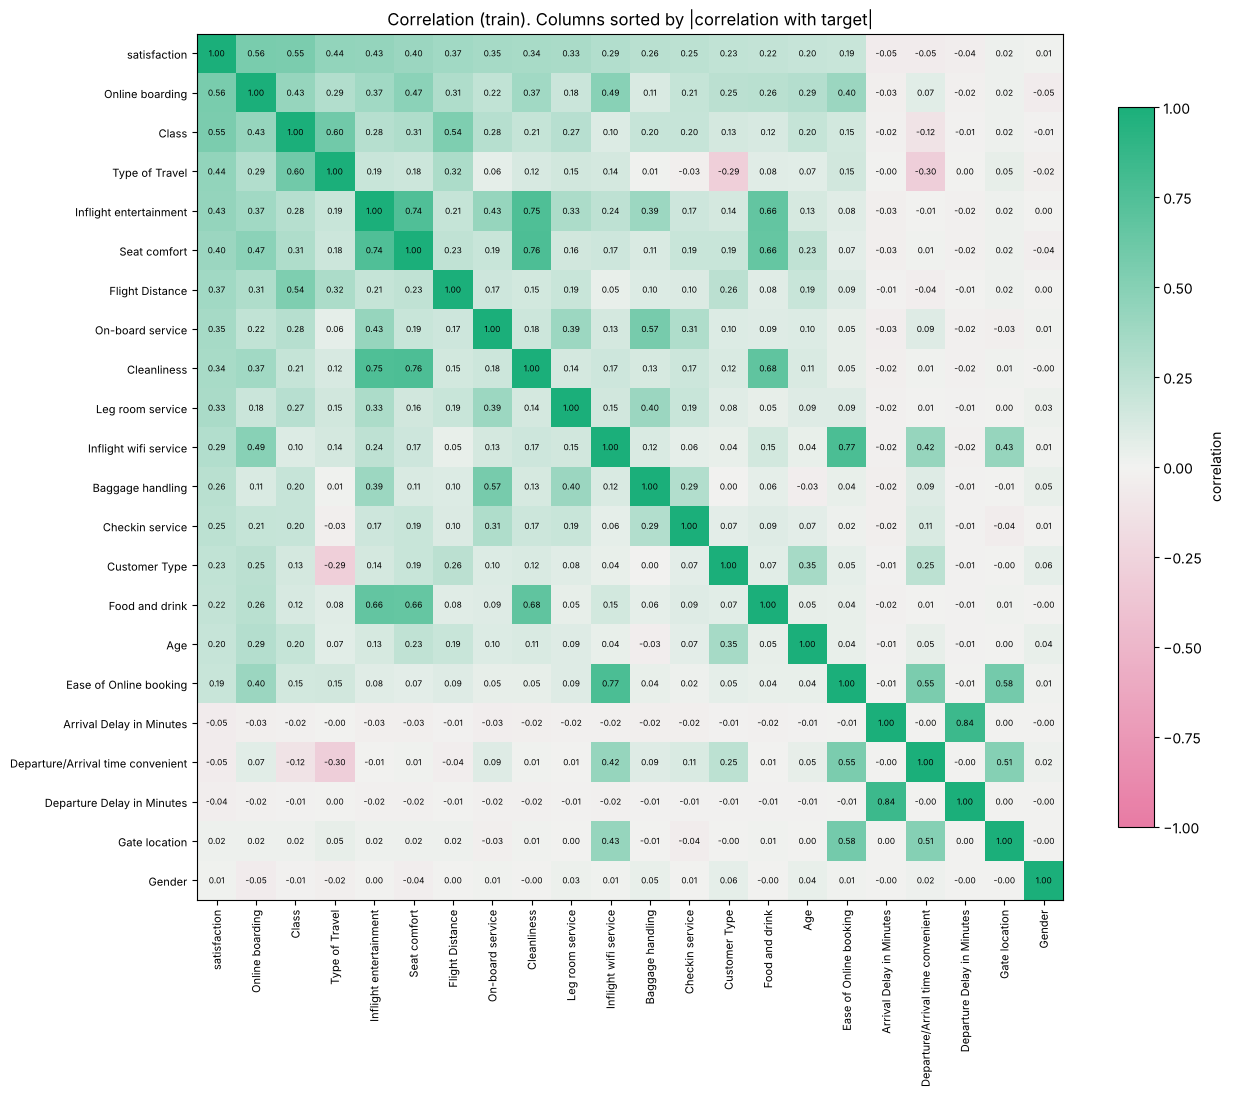

,corr with target
Online boarding,0.560
Class,0.549
Type of Travel,0.444
Inflight entertainment,0.431
Seat comfort,0.401
Flight Distance,0.370
On-board service,0.347
Cleanliness,0.339
Leg room service,0.330
Inflight wifi service,0.291


In [13]:
# 相関ヒートマップ: targetと各列、列どうしの相関(-1〜1)を色と数字で見る
# +(アクア)は一緒に増える、-(マゼンタ)は逆に動く、0に近い(灰色)は直線の関係がない
from matplotlib.colors import LinearSegmentedColormap

# 相関を計算する(列どうしのすべての組み合わせ)
corr = train_num.corr()

# targetとの相関の大きさ(絶対値)が大きい順に列を並べる。targetは先頭に置く
corr_target = corr[TARGET].drop(TARGET)
order_cols = corr_target.abs().sort_values(ascending=False).index.tolist()
order = [TARGET] + order_cols
corr = corr.loc[order, order]

# 色を決める(マイナス=マゼンタ、0=灰色、プラス=アクア)
cmap = LinearSegmentedColormap.from_list("corr", [FALSE_C, "#f2f2f0", TRUE_C])

# ヒートマップを描く
n = len(order)
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(n), order, rotation=90, fontsize=8)
ax.set_yticks(range(n), order, fontsize=8)

# 1マスずつ、相関の数字を書き込む
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6)

# 色の説明(カラーバー)とタイトル
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Correlation (train). Columns sorted by |correlation with target|")
plt.tight_layout()

# 図を保存して表示する
plt.savefig(FIG / "q8_corr_heatmap.png", dpi=120)
plt.show()

# targetとの相関だけを、大きい順に表で表示する
display(corr_target.loc[order_cols].round(3).to_frame("corr with target"))

**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## まとめ(EDA後に書く)
- `positive` の値: 
- カテゴリ列 / 欠損 / 外れ値で決めたこと:
- 次に試す特徴量: